# 05 — PhiUSIIL Thread 2 Comparison

This notebook combines the saved outputs from Aleph ILP, SVM RBF and MLP into one table and one comparison plot.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = Path.cwd()
OUTPUT_DIR = BASE_DIR / "outputs" / "thread2_comparison"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

aleph_path = BASE_DIR / "outputs" / "aleph_phiusiil" / "aleph_phiusiil_results.csv"
svm_path = BASE_DIR / "outputs" / "svm_phiusiil" / "svm_phiusiil_results.csv"
mlp_path = BASE_DIR / "outputs" / "mlp_phiusiil" / "mlp_phiusiil_results.csv"

print("Aleph results found:", aleph_path.exists())
print("SVM results found:", svm_path.exists())
print("MLP results found:", mlp_path.exists())

Aleph results found: True
SVM results found: True
MLP results found: True


In [2]:
rows = []

if aleph_path.exists():
    aleph = pd.read_csv(aleph_path)
    best_aleph = aleph.sort_values(["test_f1", "test_accuracy"], ascending=False).iloc[0]

    aleph_roc_auc = best_aleph["test_roc_auc"]

    rows.append({
        "model": "Aleph ILP",
        "accuracy": best_aleph["test_accuracy"],
        "precision": best_aleph["test_precision"],
        "recall_sensitivity": best_aleph["test_sensitivity"],
        "specificity": best_aleph["test_specificity"],
        "f1": best_aleph["test_f1"],
        "roc_auc": aleph_roc_auc,
        "interpretability": "High",
    })

if svm_path.exists():
    svm = pd.read_csv(svm_path).iloc[0]
    rows.append({
        "model": "SVM RBF",
        "accuracy": svm["accuracy"],
        "precision": svm["precision"],
        "recall_sensitivity": svm["recall_sensitivity"],
        "specificity": svm["specificity"],
        "f1": svm["f1"],
        "roc_auc": svm["roc_auc"],
        "interpretability": "Low",
    })

if mlp_path.exists():
    mlp = pd.read_csv(mlp_path).iloc[0]
    rows.append({
        "model": "MLP",
        "accuracy": mlp["accuracy"],
        "precision": mlp["precision"],
        "recall_sensitivity": mlp["recall_sensitivity"],
        "specificity": mlp["specificity"],
        "f1": mlp["f1"],
        "roc_auc": mlp["roc_auc"],
        "interpretability": "Low",
    })

comparison = pd.DataFrame(rows)
comparison.to_csv(OUTPUT_DIR / "thread2_phiusiil_comparison.csv", index=False)
display(comparison)

,model,accuracy,precision,recall_sensitivity,specificity,f1,roc_auc,interpretability
0,Aleph ILP,0.997,0.993,1.000,0.993,0.997000,0.996500,High
1,SVM RBF,0.999,1.000,0.998,1.000,0.998999,0.999992,Low
2,MLP,0.999,1.000,0.998,1.000,0.998999,0.999837,Low


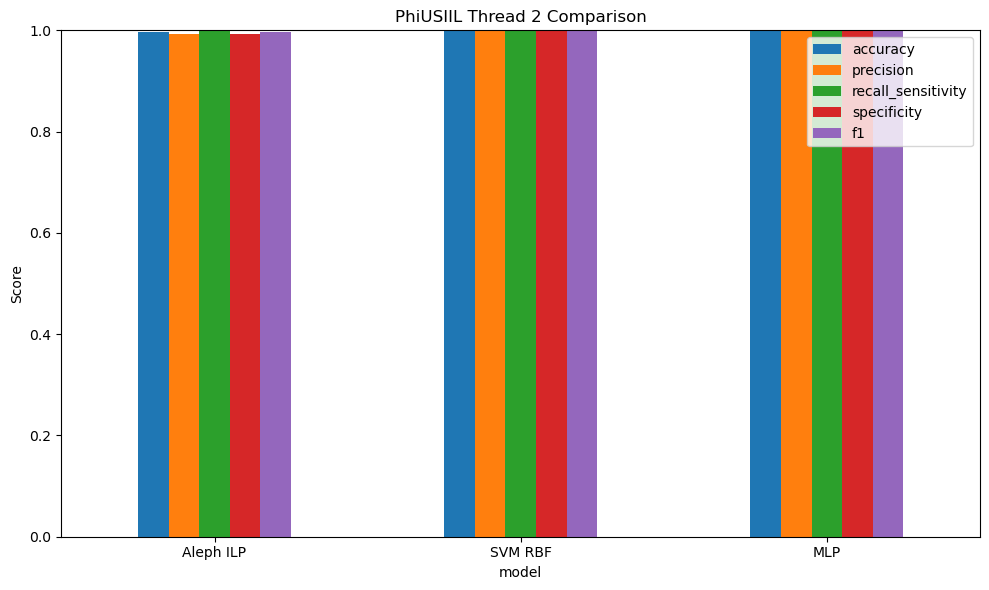

Comparison outputs saved to: c:\Users\AD\Downloads\iLostAllBrainCells\iLostAllBrainCells\phiusiil_5_member_ipynb_readme_only\member4_thread2_comparison_integration\outputs\thread2_comparison


In [3]:
plot_cols = ["accuracy", "precision", "recall_sensitivity", "specificity", "f1"]
comparison.set_index("model")[plot_cols].plot(kind="bar", figsize=(10, 6))
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("PhiUSIIL Thread 2 Comparison")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "thread2_phiusiil_comparison.png", dpi=300)
plt.show()

print("Comparison outputs saved to:", OUTPUT_DIR)